### Overview

Evaluation of word2vec-based machine learning models using SCAN-B NextSeq test set (semi-external external test set)

#### Note: Use Scipy Version 1.12 to be able to import Gensim

In [1]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import random
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Import and prepare data

In [2]:
# import tpm counts training set
train_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_train_80.csv", 
                          header=0, index_col=0)

In [3]:
# import validation data
val_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_cleaned_data/pam50genes_tpm_counts_subtype_scanb_nextseq.csv", 
                          header=0, index_col=0)

In [4]:
# keep only PAM50 gene counts
X_train = train_data.iloc[:, 0:50]
X_test = val_data.iloc[:,0:50]
print(X_train.shape)
print(X_test.shape)
print(X_train.columns.equals(X_test.columns))

(2204, 50)
(276, 50)
True


In [5]:
# save sample subtype info separately as y_train and y_test
y_train = train_data.iloc[:, [50]]
y_test = val_data.iloc[:,[50]]
print(y_train.shape)
print(y_test.shape)

(2204, 1)
(276, 1)


In [6]:
# check if the indices of x and y match
print(X_train.index.equals(y_train.index))
print(X_test.index.equals(y_test.index))

True
True


In [7]:
# label encoding
label_encoder = LabelEncoder()
y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])
y_test['subtype'] = label_encoder.transform(y_test['subtype'])

# check class count before label encoding
print("Class count before label encoding")
print("Train set\n",train_data['subtype'].value_counts())
print("\nTest set\n",val_data['subtype'].value_counts())

# check class count after label encoding
print("\nClass count after label encoding")
print("Train set\n",y_train['subtype'].value_counts())
print("\nTest set\n",y_test['subtype'].value_counts())

Class count before label encoding
Train set
 subtype
LumA     1119
LumB      654
Basal     230
Her2      201
Name: count, dtype: int64

Test set
 subtype
LumA     142
LumB      78
Basal     29
Her2      27
Name: count, dtype: int64

Class count after label encoding
Train set
 subtype
2    1119
3     654
0     230
1     201
Name: count, dtype: int64

Test set
 subtype
2    142
3     78
0     29
1     27
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_21152\535389317.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])
C:\Users\User\AppData\Local\Temp\ipykernel_21152\535389317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['subtype'] = label_encoder.transform(y_test['subtype'])


#### 2. Evaluate word2vec-based classification on the test set

In [8]:
# function to rank gene column names to create gene sentence
def get_top_genes(row):
    return row.sort_values(ascending=False).index.to_list()

In [9]:
# function to get average embedding
# need to average the word embeddings because it creates a fixed-length single vector representation for the entire sequence
# useful for machine learning models which needs a single input vector for each sample
# Word2vec creates (m,n) embedding vector for each sequence (m: number of words in the sequence, n: embedding vector size)
# each word has an embedding of shape (vector size,)
# the average of the embeddings have to be computed column wise to maintain the shape of embedding vector size
# averaging the mean row-wise is incorrect, because it reduces the embedding of an entire word into a single value.
def get_average_vector(sequence, model):
    vectors = [model.wv[word] for word in sequence if word in model.wv]
    # return a zero vector if no valid words
    if len(vectors) == 0:
        return np.zeros(model.vector_size)  
    return np.mean(vectors, axis=0)


In [10]:
# rank the gene names for all the samples in X_train
X_train_ranked_geneList = X_train.apply(lambda row: get_top_genes(row), axis=1)
X_train_ranked_geneList = pd.DataFrame(X_train_ranked_geneList , index=X_train.index, columns=['ranked_gene_list'])

In [11]:
# rank the gene names for all the samples in X_test
X_test_ranked_geneList = X_test.apply(lambda row: get_top_genes(row), axis=1)
X_test_ranked_geneList = pd.DataFrame(X_test_ranked_geneList , index=X_test.index, columns=['ranked_gene_list'])

In [12]:
print(X_train_ranked_geneList.shape)
print(X_test_ranked_geneList.shape)

(2204, 1)
(276, 1)


In [13]:
seed = 42
np.random.seed(seed)
random.seed(seed)

#### 2.1 Random Forest

In [14]:
random.seed(seed)
np.random.seed(seed)

# train word2vec (using the optimal parameters)
w2v_model_rf = Word2Vec(X_train_ranked_geneList['ranked_gene_list'], vector_size=800, sg=1, alpha=0.01, window=6, epochs=10,
                         seed=seed, workers=1)

# Convert each sequence of each sample to average word embedding vector and save it as a 2d array
x_train_vect_rf = np.array([get_average_vector(seq, w2v_model_rf) for seq in X_train_ranked_geneList['ranked_gene_list']])
x_test_vect_rf = np.array([get_average_vector(seq, w2v_model_rf) for seq in X_test_ranked_geneList['ranked_gene_list']])

print('Embedding vector sequence in training: ',len(x_train_vect_rf[0]))
print('Embedding vector sequence in validation: ',len(x_test_vect_rf[0]))
print('Embedding vector shape in training: ',x_train_vect_rf.shape)
print('Embedding vector shape in validation: ',x_test_vect_rf.shape)

# standardization of the embedding vectors
scaler = StandardScaler()
x_train_vect_scaled_rf = scaler.fit_transform(x_train_vect_rf)
x_test_vect_scaled_rf = scaler.transform(x_test_vect_rf)

print('Embedding vector shape in training after scaling: ',x_train_vect_scaled_rf.shape)
print('Embedding vector shape in test after scaling: ',x_test_vect_scaled_rf.shape)

# pca transformation
pca_rf = PCA(random_state=seed, n_components=14)
x_train_pca_rf = pca_rf.fit_transform(x_train_vect_scaled_rf)
x_test_pca_rf = pca_rf.transform(x_test_vect_scaled_rf)

print(f'Shape of training and test after PCA: {x_train_pca_rf.shape} and {x_test_pca_rf.shape}')

# build rf classifier
rfc = RandomForestClassifier(n_estimators=100, min_samples_leaf=1, min_samples_split=2, random_state=seed)

# fit the rf classifier on the training fold sets
rfc.fit(x_train_pca_rf, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_rf = rfc.predict(x_test_pca_rf)

# calculate metric scores
mcc_rf = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_rf)
f1_rf = metrics.f1_score(y_test.values.ravel(), y_pred_rf, average='macro')
recall_rf = metrics.recall_score(y_test.values.ravel(), y_pred_rf, average='macro')
precision_rf = metrics.precision_score(y_test.values.ravel(), y_pred_rf, average='macro')
accuracy_rf = metrics.accuracy_score(y_test.values.ravel(), y_pred_rf)

print(metrics.classification_report(y_test.values.ravel(), y_pred_rf, digits=4))


Embedding vector sequence in training:  800
Embedding vector sequence in validation:  800
Embedding vector shape in training:  (2204, 800)
Embedding vector shape in validation:  (276, 800)
Embedding vector shape in training after scaling:  (2204, 800)
Embedding vector shape in test after scaling:  (276, 800)
Shape of training and test after PCA: (2204, 14) and (276, 14)
              precision    recall  f1-score   support

           0     1.0000    0.9310    0.9643        29
           1     0.9259    0.9259    0.9259        27
           2     0.9379    0.9577    0.9477       142
           3     0.8831    0.8718    0.8774        78

    accuracy                         0.9275       276
   macro avg     0.9367    0.9216    0.9288       276
weighted avg     0.9278    0.9275    0.9275       276



In [15]:
print('Accuracy: ', round(accuracy_rf,4))
print('Macro Precision: ', round(precision_rf,4))
print('Macro Recall: ', round(recall_rf,4))
print('Macro F1: ', round(f1_rf,4))
print('Macro MCC: ', round(mcc_rf,4))

Accuracy:  0.9275
Macro Precision:  0.9367
Macro Recall:  0.9216
Macro F1:  0.9288
Macro MCC:  0.8853


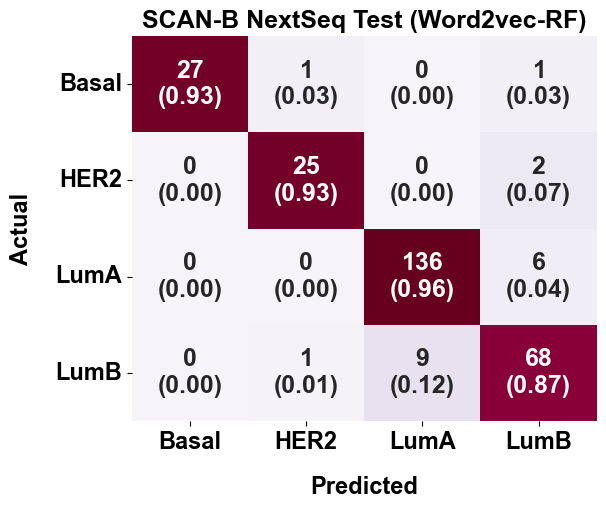

In [16]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_rf, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_rf, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('SCAN-B NextSeq Test (Word2vec-RF)', fontsize=18, fontfamily='Arial', weight='bold')
plt.show()

#### 2.2 SVM

In [17]:
random.seed(seed)
np.random.seed(seed)

# train word2vec (using the optimal parameters)
w2v_model_svm = Word2Vec(X_train_ranked_geneList['ranked_gene_list'], vector_size=600, sg=1, alpha=0.01, window=5, epochs=5,
                         seed=seed, workers=1)

# Convert each sequence of each sample to average word embedding vector and save it as a 2d array
x_train_vect_svm = np.array([get_average_vector(seq, w2v_model_svm) for seq in X_train_ranked_geneList['ranked_gene_list']])
x_test_vect_svm = np.array([get_average_vector(seq, w2v_model_svm) for seq in X_test_ranked_geneList['ranked_gene_list']])

print('Embedding vector sequence in training: ',len(x_train_vect_svm[0]))
print('Embedding vector sequence in validation: ',len(x_test_vect_svm[0]))
print('Embedding vector shape in training: ',x_train_vect_svm.shape)
print('Embedding vector shape in validation: ',x_test_vect_svm.shape)

# standardization of the embedding vectors
scaler = StandardScaler()
x_train_vect_scaled_svm = scaler.fit_transform(x_train_vect_svm)
x_test_vect_scaled_svm = scaler.transform(x_test_vect_svm)

print('Embedding vector shape in training after scaling: ',x_train_vect_scaled_svm.shape)
print('Embedding vector shape in test after scaling: ',x_test_vect_scaled_svm.shape)

# pca transformation
pca_svm = PCA(random_state=seed, n_components=72)
x_train_pca_svm = pca_svm.fit_transform(x_train_vect_scaled_svm)
x_test_pca_svm = pca_svm.transform(x_test_vect_scaled_svm)

print(f'Shape of training and test after PCA: {x_train_pca_svm.shape} and {x_test_pca_svm.shape}')
    
# build svm classifier
svm = SVC(C=1, gamma='scale', kernel='rbf', random_state=seed)

# fit the svm classifier on the training fold sets
svm.fit(x_train_pca_svm, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_svm = svm.predict(x_test_pca_svm)

# calculate metric scores
mcc_svm = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_svm)
f1_svm = metrics.f1_score(y_test.values.ravel(), y_pred_svm, average='macro')
recall_svm = metrics.recall_score(y_test.values.ravel(), y_pred_svm, average='macro')
precision_svm = metrics.precision_score(y_test.values.ravel(), y_pred_svm, average='macro')
accuracy_svm = metrics.accuracy_score(y_test.values.ravel(), y_pred_svm)

print(metrics.classification_report(y_test.values.ravel(), y_pred_svm, digits=4))


Embedding vector sequence in training:  600
Embedding vector sequence in validation:  600
Embedding vector shape in training:  (2204, 600)
Embedding vector shape in validation:  (276, 600)
Embedding vector shape in training after scaling:  (2204, 600)
Embedding vector shape in test after scaling:  (276, 600)
Shape of training and test after PCA: (2204, 72) and (276, 72)
              precision    recall  f1-score   support

           0     1.0000    0.9310    0.9643        29
           1     0.9286    0.9630    0.9455        27
           2     0.9456    0.9789    0.9619       142
           3     0.9459    0.8974    0.9211        78

    accuracy                         0.9493       276
   macro avg     0.9550    0.9426    0.9482       276
weighted avg     0.9497    0.9493    0.9490       276



In [18]:
print('Accuracy: ', round(accuracy_svm,4))
print('Macro Precision: ', round(precision_svm,4))
print('Macro Recall: ', round(recall_svm,4))
print('Macro F1: ', round(f1_svm,4))
print('Macro MCC: ', round(mcc_svm,4))

Accuracy:  0.9493
Macro Precision:  0.955
Macro Recall:  0.9426
Macro F1:  0.9482
Macro MCC:  0.92


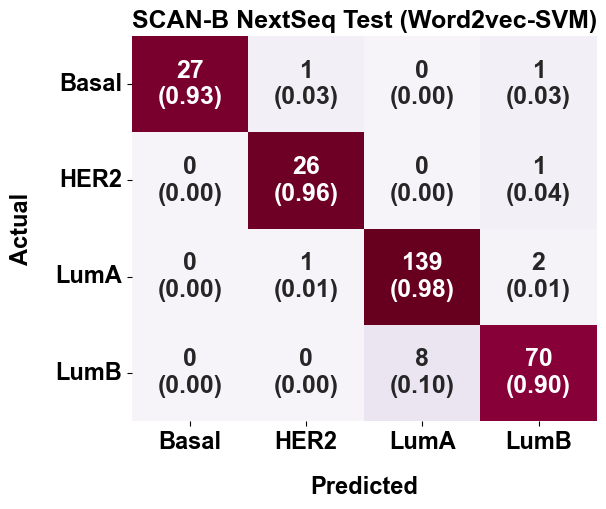

In [19]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_svm, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_svm, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('SCAN-B NextSeq Test (Word2vec-SVM)', fontsize=18, fontfamily='Arial', weight='bold')
# plt.savefig('scanb_nextseq_test_word2vec_svm_confusionmatrix.png',dpi=300, bbox_inches='tight')
plt.show()

#### 2.3 Logistic Regression

In [20]:
random.seed(seed)
np.random.seed(seed)

# train word2vec (using the optimal parameters)
w2v_model_lr = Word2Vec(X_train_ranked_geneList['ranked_gene_list'], vector_size=900, sg=1, alpha=0.05,  window=3, epochs=5,
                         seed=seed, workers=1)

# Convert each sequence of each sample to average word embedding vector and save it as a 2d array
x_train_vect_lr = np.array([get_average_vector(seq, w2v_model_lr) for seq in X_train_ranked_geneList['ranked_gene_list']])
x_test_vect_lr = np.array([get_average_vector(seq, w2v_model_lr) for seq in X_test_ranked_geneList['ranked_gene_list']])

print('Embedding vector sequence in training: ',len(x_train_vect_lr[0]))
print('Embedding vector sequence in validation: ',len(x_test_vect_lr[0]))
print('Embedding vector shape in training: ',x_train_vect_lr.shape)
print('Embedding vector shape in validation: ',x_test_vect_lr.shape)

# standardization of the embedding vectors
scaler = StandardScaler()
x_train_vect_scaled_lr = scaler.fit_transform(x_train_vect_lr)
x_test_vect_scaled_lr = scaler.transform(x_test_vect_lr)

print('Embedding vector shape in training after scaling: ',x_train_vect_scaled_lr.shape)
print('Embedding vector shape in test after scaling: ',x_test_vect_scaled_lr.shape)

# pca transformation
pca = PCA(random_state=seed, n_components=18)
x_train_pca_lr = pca.fit_transform(x_train_vect_scaled_lr)
x_test_pca_lr = pca.transform(x_test_vect_scaled_lr)

print(f'Shape of training and test after PCA: {x_train_pca_lr.shape} and {x_test_pca_lr.shape}')
    
# build logistic regression classifier
lr = LogisticRegression(C=0.05, solver='saga', penalty='l2', random_state=seed, max_iter=1000)

# fit the logistic regression classifier on the training fold sets
lr.fit(x_train_pca_lr, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_logreg = lr.predict(x_test_pca_lr)

# calculate metric scores
mcc_logreg = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_logreg)
f1_logreg = metrics.f1_score(y_test.values.ravel(), y_pred_logreg, average='macro')
recall_logreg = metrics.recall_score(y_test.values.ravel(), y_pred_logreg, average='macro')
precision_logreg = metrics.precision_score(y_test.values.ravel(), y_pred_logreg, average='macro')
accuracy_logreg = metrics.accuracy_score(y_test.values.ravel(), y_pred_logreg)

print(metrics.classification_report(y_test.values.ravel(), y_pred_logreg, digits=4))



Embedding vector sequence in training:  900
Embedding vector sequence in validation:  900
Embedding vector shape in training:  (2204, 900)
Embedding vector shape in validation:  (276, 900)
Embedding vector shape in training after scaling:  (2204, 900)
Embedding vector shape in test after scaling:  (276, 900)
Shape of training and test after PCA: (2204, 18) and (276, 18)
              precision    recall  f1-score   support

           0     1.0000    0.9310    0.9643        29
           1     0.8966    0.9630    0.9286        27
           2     0.9392    0.9789    0.9586       142
           3     0.9306    0.8590    0.8933        78

    accuracy                         0.9384       276
   macro avg     0.9416    0.9330    0.9362       276
weighted avg     0.9390    0.9384    0.9378       276



In [21]:
print('Accuracy: ', round(accuracy_logreg,4))
print('Macro Precision: ', round(precision_logreg,4))
print('Macro Recall: ', round(recall_logreg,4))
print('Macro F1: ', round(f1_logreg,4))
print('Macro MCC: ', round(mcc_logreg,4))

Accuracy:  0.9384
Macro Precision:  0.9416
Macro Recall:  0.933
Macro F1:  0.9362
Macro MCC:  0.903


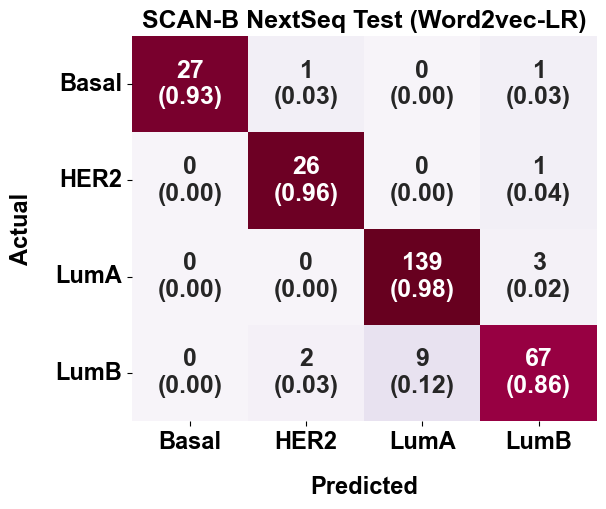

In [22]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_logreg, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_logreg, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('SCAN-B NextSeq Test (Word2vec-LR)', fontsize=18, fontfamily='Arial', weight='bold')
plt.show()

#### 3. Merge predicted labels of SVM (best model) with actual labels and survival data

This was created for survival analysis based on model predictions.

In [23]:
# import survival and subtype data of validation set
val_survival_subtype = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_survival_data/scanb_nextseq_survival_subtype.csv",
                                           header=0, index_col=0)

# reorder the index in survival data according to the counts_subtype data
val_survival_subtype = val_survival_subtype.loc[val_data.index,:]
print('Index of survival data matches with index of gene exp data:', val_survival_subtype.index.equals(val_data.index))

# check whether the subtype column in subtype data is same as subtype column in gene exp data
print('Subtype column of survival data matches with subtype column of gene exp data:',
      val_survival_subtype['subtype'].tolist() == val_data['subtype'].tolist())

Index of survival data matches with index of gene exp data: True
Subtype column of survival data matches with subtype column of gene exp data: True


In [24]:
# define best model
best_model_res = y_pred_svm

# define labels to transform the numeric class labels into subtype names
labels_reverse = {0: 'Basal', 1: 'Her2', 2: 'LumA', 3: 'LumB'}

# convert predicted results of best model into a df
best_model_res_df = pd.DataFrame(best_model_res, index=y_test.index, columns=['predicted_subtype'])
best_model_res_df['predicted_subtype'] = best_model_res_df['predicted_subtype'].replace(labels_reverse)
best_model_res_df['predicted_subtype'].value_counts()

predicted_subtype
LumA     147
LumB      74
Her2      28
Basal     27
Name: count, dtype: int64

In [25]:
# merge survival data, actual labels and predicted labels
best_model_res_survival = val_survival_subtype.join(best_model_res_df)

# get the count of misclassifications
print('Number of misclassifications:', best_model_res_survival.loc[best_model_res_survival['subtype'] 
      != best_model_res_survival['predicted_subtype'],:].shape)

Number of misclassifications: (14, 5)


In [26]:
# check overall survival events
print("Survival event proportion:")
print(best_model_res_survival['overall_survival_event'].value_counts())

# check overall survival events as per actual labels
print("\nSurvival event proportion based on actual subtype labels:")
# check survival events with actual labels
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'LumA', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'LumB', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'Her2', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'Basal', 'overall_survival_event'].value_counts())

# check overall survival events as per predicted labels
print("\nSurvival event proportion based on predicted subtype labels:")
# check survival events with actual labels
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'LumA', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'LumB', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'Her2', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'Basal', 'overall_survival_event'].value_counts())

Survival event proportion:
overall_survival_event
0    237
1     39
Name: count, dtype: int64

Survival event proportion based on actual subtype labels:
overall_survival_event
0    126
1     16
Name: count, dtype: int64
overall_survival_event
0    67
1    11
Name: count, dtype: int64
overall_survival_event
0    18
1     9
Name: count, dtype: int64
overall_survival_event
0    26
1     3
Name: count, dtype: int64

Survival event proportion based on predicted subtype labels:
overall_survival_event
0    131
1     16
Name: count, dtype: int64
overall_survival_event
0    63
1    11
Name: count, dtype: int64
overall_survival_event
0    19
1     9
Name: count, dtype: int64
overall_survival_event
0    24
1     3
Name: count, dtype: int64


In [27]:
# # save predicted + actual labels + survival data
# best_model_res_survival.to_csv('scanb_nextseq_test_wordvecpca_svm_predictions.csv')